In [ ]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

In [ ]:
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    "ELGnotqso": "ELG",
    "QSO": "QSO",
}

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [ ]:
scale_cut = [0.3, 3]
version = "vF"
data_path = (
    f"{ROOT}/results/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_{version}.npz"
)
print(f"Loading from {data_path}...")
data = np.load(data_path)
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]
print(data.files)

Loading from results/merged_res_norm_0.3_3_vF.npz...
['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


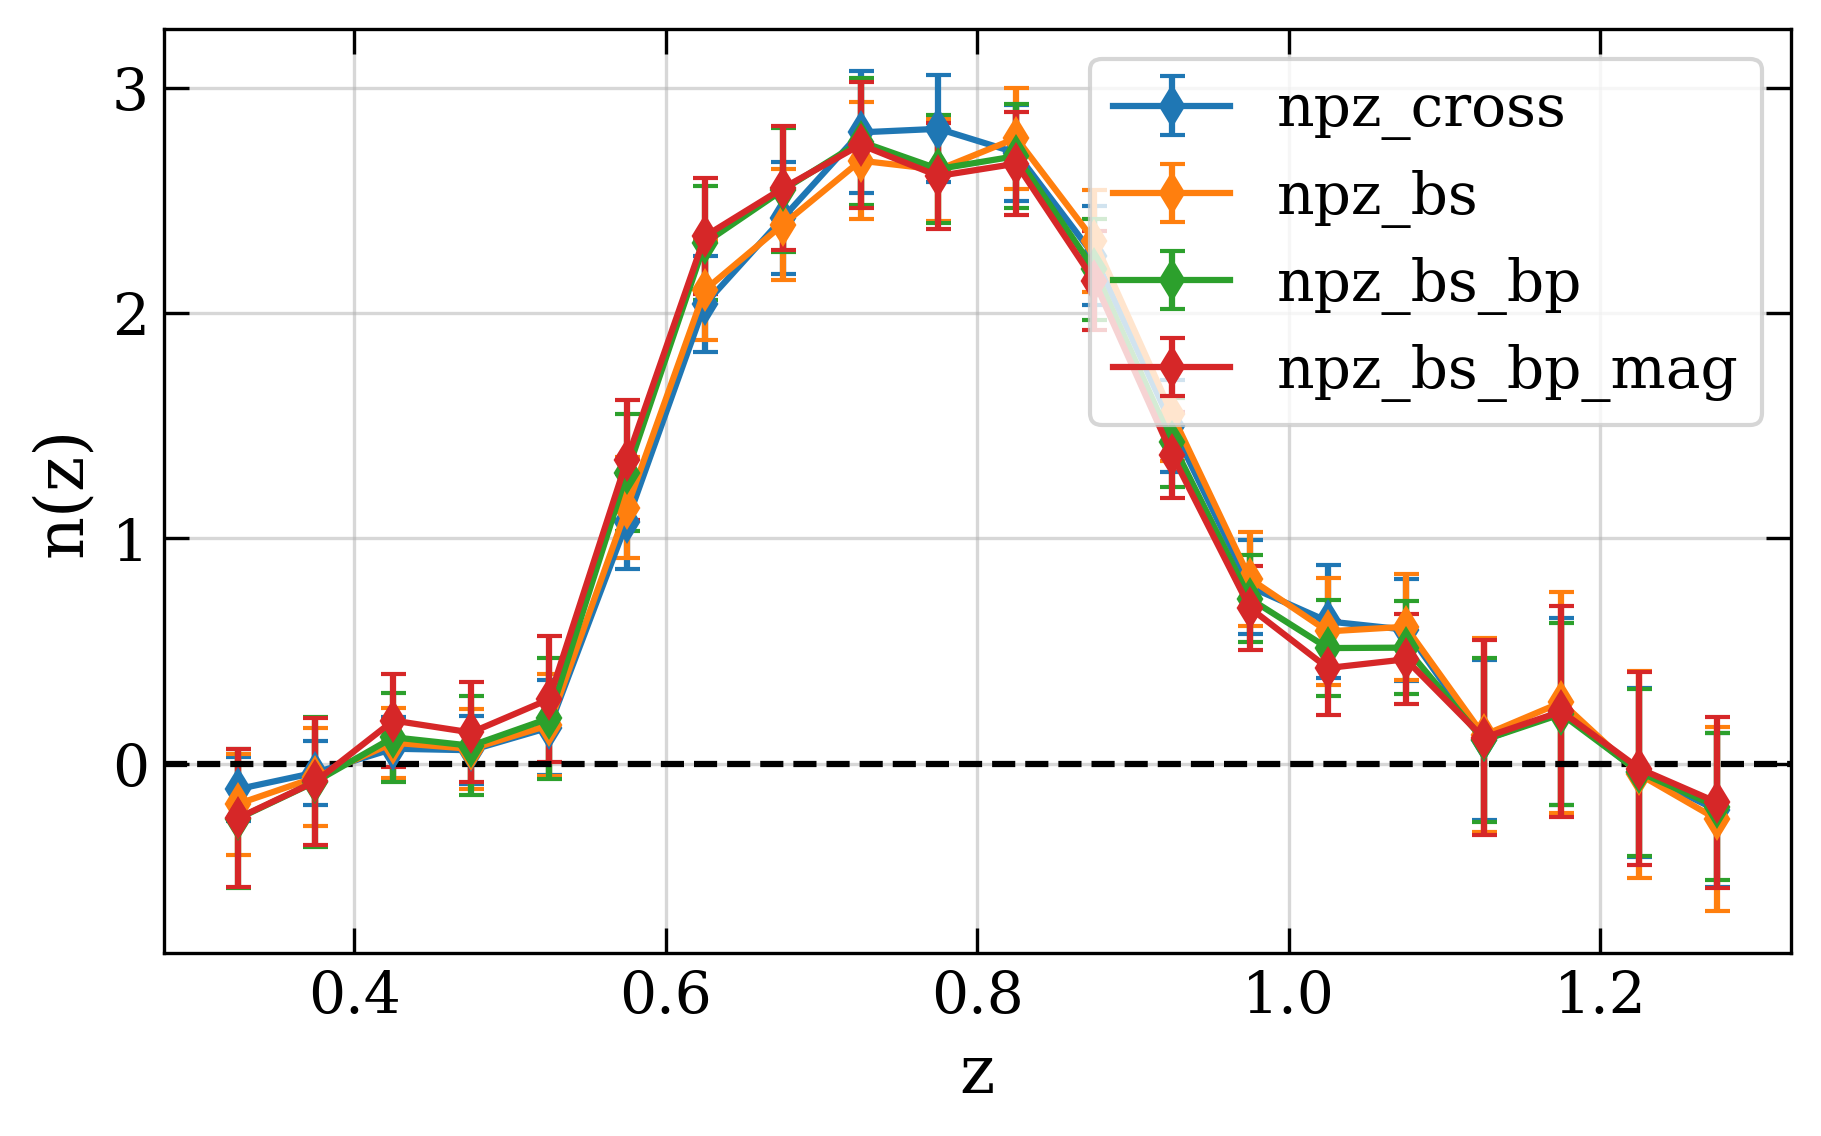

In [5]:
plt.figure(figsize=(7, 4))
tomo = 2
z = [data[f"{tomo}/{name}_z"] for name in names]
npz = [data[f"{tomo}/{name}"] for name in names]
npz_err = [data[f"{tomo}/{name}_err"] for name in names]

for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, marker="d", label=name)
plt.legend(loc="upper right")
plt.grid(True)
plt.ylabel("n(z)")
plt.xlabel("z")
plt.axhline(0, color="black", linestyle="--")

In [ ]:
importlib.reload(spline)
for sc in [[0.3, 3], [1, 5]]:  # [1, 5]
    print(f"Processing scale cut {sc}")
    data = np.load(f"{ROOT}/results/merged_res_norm_{sc[0]}_{sc[1]}_{version}.npz")
    dir_splines = Path(f"{ROOT}/results/splines_{sc[0]}_{sc[1]}_{version}")
    if not dir_splines.exists():
        dir_splines.mkdir(parents=True)
    for i, name in enumerate(names):
        for tomo in range(1, 5):
            savefile = str(dir_splines / f"spl_{name}_{tomo}")
            npz_arr = data[f"{tomo}/{name}"]
            npz_arr_err = data[f"{tomo}/{name}_err"]
            z = data[f"{tomo}/{name}_z"]

            if Path(f"{savefile}.nc").exists():
                print(f"Skipping {savefile}, already exists")
                continue

            spl = spline.BayesianBSpline(zv=z, n_knots=int(len(z) // 2))
            spl.fit(
                npz_arr,
                npz_arr_err,
                n_tune=400,
                n_samples=1600,
                target_accept=0.99,
                prior_concentration=3,
                base_alpha=0.05,
            )
            spl.save_model(savefile)